# Setup and Imports

In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error


# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

# Understand Data

In [55]:
# df = pd.read_csv('/kaggle/input/datasets/ruchikakumbhar/calories-burnt-prediction/calories.csv')
df = pd.read_csv('calories.csv')
df.head() # Inspect first rows

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0


In [56]:
df.info() # Check null values and dtypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   User_ID     15000 non-null  int64  
 1   Gender      15000 non-null  object 
 2   Age         15000 non-null  int64  
 3   Height      15000 non-null  float64
 4   Weight      15000 non-null  float64
 5   Duration    15000 non-null  float64
 6   Heart_Rate  15000 non-null  float64
 7   Body_Temp   15000 non-null  float64
 8   Calories    15000 non-null  float64
dtypes: float64(6), int64(2), object(1)
memory usage: 1.0+ MB


In [57]:
df.describe() # Briefly inspect if biological measures make sense

,User_ID,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
count,1.500000e+04,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,1.497736e+07,42.789800,174.465133,74.966867,15.530600,95.518533,40.025453,89.539533
std,2.872851e+06,16.980264,14.258114,15.035657,8.319203,9.583328,0.779230,62.456978
min,1.000116e+07,20.000000,123.000000,36.000000,1.000000,67.000000,37.100000,1.000000
25%,1.247419e+07,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000,35.000000
50%,1.499728e+07,39.000000,175.000000,74.000000,16.000000,96.000000,40.200000,79.000000
75%,1.744928e+07,56.000000,185.000000,87.000000,23.000000,103.000000,40.600000,138.000000
max,1.999965e+07,79.000000,222.000000,132.000000,30.000000,128.000000,41.500000,314.000000


In [58]:
df.duplicated().sum() # check for duplicate rows

np.int64(0)

In [59]:
df.drop("User_ID", axis=1, inplace=True) # Drop unrelated column
df.head()

,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,female,27,154.0,58.0,10.0,81.0,39.8,35.0


# Exploratory Data Analysis

In [60]:
X = df.drop("Calories", axis=1)
y = df["Calories"]

In [61]:
num_columns = X.select_dtypes(include=["int64", "float64"]).columns
cat_columns = X.select_dtypes(include=["object"]).columns

Age: 0 potential outliers (limits: -14.00 - 98.00)


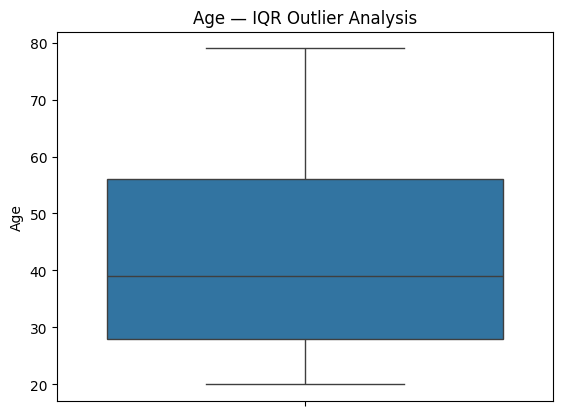

Height: 14 potential outliers (limits: 132.50 - 216.50)


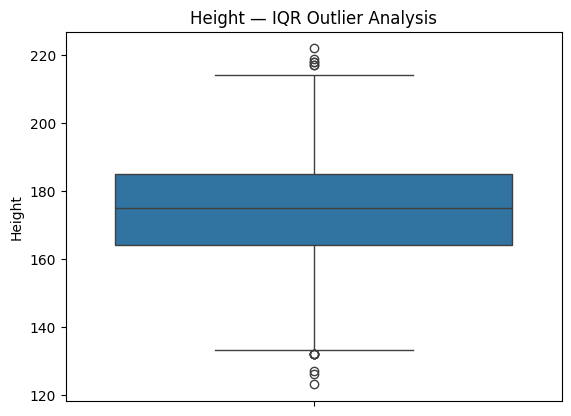

Weight: 6 potential outliers (limits: 27.00 - 123.00)


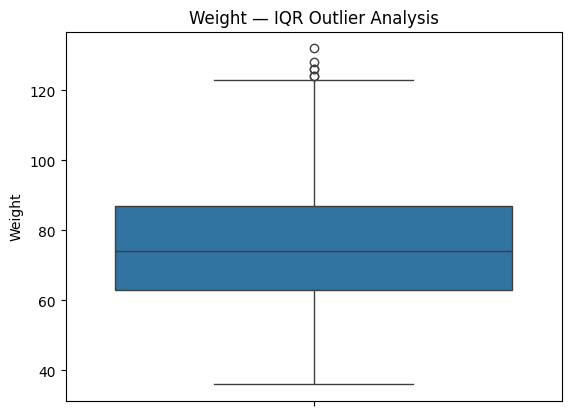

Duration: 0 potential outliers (limits: -14.50 - 45.50)


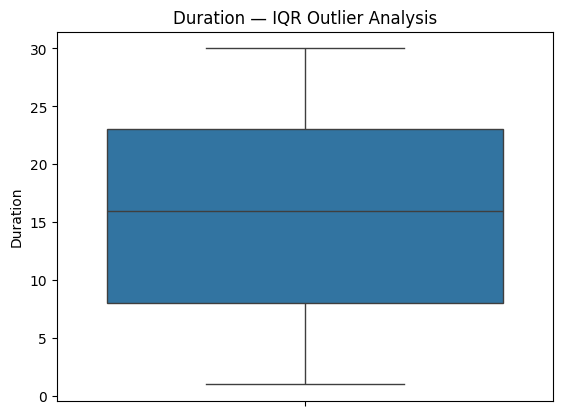

Heart_Rate: 1 potential outliers (limits: 65.50 - 125.50)


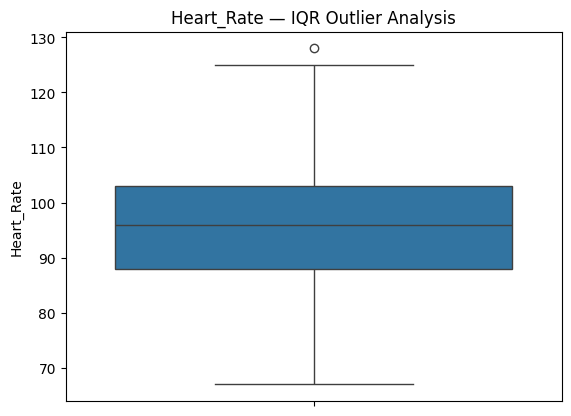

Body_Temp: 369 potential outliers (limits: 38.10 - 42.10)


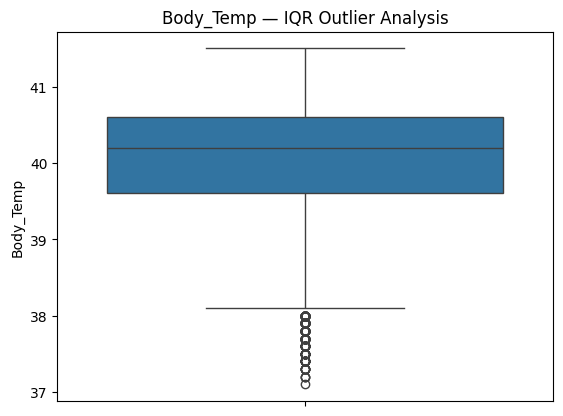

In [62]:
def visualize_outliers(data, target_c):
    """
    Visualize potential outliers using the IQR method.
    No observations are removed or capped.

    Parameters:
    - data: DataFrame
    - target_c: str
        The target column to exclude from visualization.
    """
    
    numeric_columns = data.select_dtypes(include="number").columns
    for c in numeric_columns:
        if c == target_c:
            continue

        Q1 = data[c].quantile(0.25)
        Q3 = data[c].quantile(0.75)
        IQR = Q3 - Q1

        lower_limit = Q1 - 1.5 * IQR
        upper_limit = Q3 + 1.5 * IQR

        outliers = data[
            (data[c] < lower_limit) |
            (data[c] > upper_limit)
        ]

        print(
            f"{c}: {len(outliers)} potential outliers "
            f"(limits: {lower_limit:.2f} - {upper_limit:.2f})"
        )

        sns.boxplot(data[c])
        plt.title(f"{c} — IQR Outlier Analysis")
        plt.show()


visualize_outliers(df, target_c="Calories")

<Axes: xlabel='Gender', ylabel='Count'>

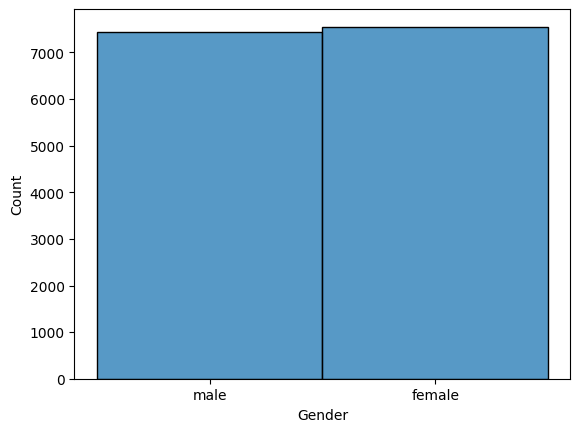

In [63]:
sns.histplot(data=df, x="Gender")

- Weight contains several statistically extreme observations (120-132 kg), but these values remain physiologically plausible. Therefore, they were retained to preserve realistic variation in the population.
- Heights below 147 cm are inspected as an exploratory subset of shorter individuals, not as a clinical cutoff or evidence of a weight-related problem. BMI is calculated to examine weight relative to height, and height-weight combinations are reviewed for possible data-quality issues; short height alone is not a reason to exclude an observation.

In [64]:
df["BMI"] = df["Weight"] / (df["Height"] / 100) ** 2
df

,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories,BMI
0,male,68,190.0,94.0,29.0,105.0,40.8,231.0,26.038781
1,female,20,166.0,60.0,14.0,94.0,40.3,66.0,21.773842
2,male,69,179.0,79.0,5.0,88.0,38.7,26.0,24.655910
3,female,34,179.0,71.0,13.0,100.0,40.5,71.0,22.159109
4,female,27,154.0,58.0,10.0,81.0,39.8,35.0,24.456063
...,...,...,...,...,...,...,...,...,...
14995,female,20,193.0,86.0,11.0,92.0,40.4,45.0,23.087868
14996,female,27,165.0,65.0,6.0,85.0,39.2,23.0,23.875115
14997,female,43,159.0,58.0,16.0,90.0,40.1,75.0,22.942130
14998,male,78,193.0,97.0,2.0,84.0,38.3,11.0,26.040968


In [65]:
for gender, group in df[df['BMI'] < 18.5].groupby('Gender'):
    print(f"\n{gender}")
    display(group)

In [66]:
df[(df["Height"] < 147) & (df["Weight"] > 80)][["Gender", "Age", "Height", "Weight", "BMI"]]

,Gender,Age,Height,Weight,BMI


- These exploratory checks did not provide sufficient evidence to exclude the flagged observations in Weight or Height. Although some values were statistically extreme, they remained physiologically plausible, and important to describe this population, so all observations were retained. 
- Outlier treatment depends on the final application. In this case, the observations identified beyond the IQR thresholds were retained because they represent valid and relevant segments of the population and may contribute meaningful information to the model.

<Axes: >

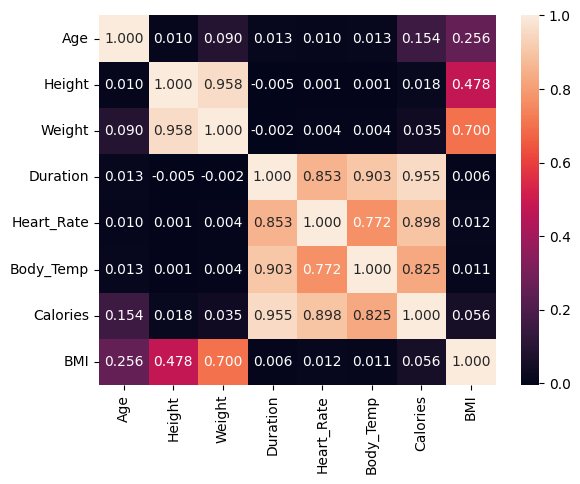

In [67]:
correlations = df.corr(numeric_only=True)

sns.heatmap(correlations, annot=True, fmt=".3f")

# Feature Preparation and Train-Test Split

In [68]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)

In [69]:
preprocessor = ColumnTransformer(
    transformers=[
        ('gender', OneHotEncoder(drop='first', handle_unknown="ignore"), cat_columns),
        ('scaler', StandardScaler(), num_columns)
    ],
    remainder="passthrough")


# Model Definitions

In [70]:
models = {
    "LinearRegression":LinearRegression(),
    "DecisionTree":DecisionTreeRegressor(max_depth=10, random_state=42),
    "RandomForest":RandomForestRegressor(n_estimators=50,max_depth=10,random_state=42),
    "GradientBoosting":GradientBoostingRegressor(n_estimators=50,random_state=42),
    "XGBoost":XGBRegressor(random_state=42),
    "CatBoost": CatBoostRegressor(iterations=500, learning_rate=0.05, depth=6, random_seed=42, verbose=0)
}

# Cross-Validation

In [71]:
from sklearn.model_selection import cross_val_score

cv_metrics = []

for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessing", preprocessor),
        ("model", model)
    ])

    cv_scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=5,
        scoring="r2"
    )

    cv_metrics.append({
        "Model": name,
        "CV1": cv_scores[0],
        "CV2": cv_scores[1],
        "CV3": cv_scores[2],
        "CV4": cv_scores[3],
        "CV5": cv_scores[4],
        "Mean CV R²": cv_scores.mean()
    })

cv_metrics_df = pd.DataFrame(cv_metrics)

cv_metrics_df.sort_values(
    by="Mean CV R²",
    ascending=False
)

,Model,CV1,CV2,CV3,CV4,CV5,Mean CV R²
5,CatBoost,0.999635,0.999664,0.999592,0.999671,0.999705,0.999653
4,XGBoost,0.998723,0.998780,0.998552,0.998540,0.998628,0.998645
2,RandomForest,0.996557,0.996740,0.996112,0.996664,0.996390,0.996493
3,GradientBoosting,0.992167,0.993196,0.992052,0.992949,0.992900,0.992653
1,DecisionTree,0.990853,0.989659,0.990176,0.990112,0.990242,0.990208
0,LinearRegression,0.966291,0.965960,0.968093,0.967764,0.967031,0.967028


# Model Evaluation and Comparison

In [72]:
model_metrics = []

for name, model in models.items():
    pipeline = Pipeline([
        ("preprocessing", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    # Evaluation metrics
    mae = mean_absolute_error(y_test,y_pred)
    rmse = np.sqrt(mean_squared_error(y_test,y_pred))
    test_r2 = r2_score(y_test,y_pred)

    model_metrics.append({
        "Model":name,
        "MAE":round(mae, 2),
        "RMSE":round(rmse, 2),
        "R2":round(test_r2, 4),
        "Mean CV R²":cv_scores.mean()
    })

model_metrics_df = pd.DataFrame(model_metrics)
model_metrics_df = model_metrics_df.sort_values(by="R2", ascending=False)
model_metrics_df

,Model,MAE,RMSE,R2,Mean CV R²
5,CatBoost,0.79,1.07,0.9997,0.999653
4,XGBoost,1.50,2.14,0.9989,0.999653
2,RandomForest,2.29,3.40,0.9971,0.999653
3,GradientBoosting,3.67,5.18,0.9933,0.999653
1,DecisionTree,3.95,5.79,0.9917,0.999653
0,LinearRegression,8.44,11.49,0.9673,0.999653


CatBoost achieved the best cross-validation and test scores in this analysis, while performance on independent exercise data remains to be evaluated.